In [1]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 10.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.7 MB/s eta 0:00:00:00:01


In [2]:
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

In [3]:
path = untar_data(URLs.MNIST_SAMPLE)
path

<div><progress max="3214948" value="3219456"></progress> 100.14% [3219456/3214948 00:00&lt;00:00]</div>

Path('/root/.fastai/data/mnist_sample')

In [4]:
path.ls()

[Path('/root/.fastai/data/mnist_sample/valid'), Path('/root/.fastai/data/mnist_sample/labels.csv'), Path('/root/.fastai/data/mnist_sample/train')]

In [5]:
Path.BASE_PATH = path
Path.BASE_PATH

Path('.')

In [6]:
path

Path('.')

In [7]:
path.ls()

[Path('valid'), Path('labels.csv'), Path('train')]

In [8]:
(path/'train').ls()

[Path('train/7'), Path('train/3')]

In [9]:
threes = (path/'train/3').ls().sorted()
sevens = (path/'train/7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'), Path('train/3/10000.png'), Path('train/3/10011.png'), Path('train/3/10031.png'), Path('train/3/10034.png'), Path('train/3/10042.png'), Path('train/3/10052.png'), Path('train/3/1007.png'), Path('train/3/10074.png'), Path('train/3/10091.png'), Path('train/3/10093.png'), Path('train/3/10097.png'), Path('train/3/10099.png'), Path('train/3/10116.png'), Path('train/3/10125.png'), Path('train/3/10137.png'), Path('train/3/10141.png'), Path('train/3/10144.png'), Path('train/3/10155.png'), Path('train/3/10161.png'), Path('train/3/10206.png'), Path('train/3/1021.png'), Path('train/3/10210.png'), Path('train/3/10214.png'), Path('train/3/10238.png'), Path('train/3/10260.png'), Path('train/3/10278.png'), Path('train/3/10282.png'), Path('train/3/10314.png'), Path('train/3/10322.png'), Path('train/3/10328.png'), Path('train/3/10329.png'), Path('train/3/10330.png'), Path('train/3/10349.png'), Path('train/3/1035.png'), Path('train/3/10360.png'), Path('train/3/10369.png')

In [10]:
img3_path = threes[1]
img = Image.open(img3_path)
img

In [11]:
array(img)[4:10, 4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

In [12]:
tensor(img)[4:10, 4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

In [13]:
img_t = tensor(img)
df = pd.DataFrame(img_t[4:15, 4:22])
df.style.set_properties(**{'font-size': '6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


In [14]:
sevens_tensors = [tensor(Image.open(p)) for p in sevens]
threes_tensors = [tensor(Image.open(p)) for p in threes]
len(sevens_tensors),len(threes_tensors)

(6265, 6131)

<Axes: >

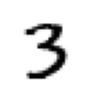

In [15]:
show_image(threes_tensors[1])

In [16]:
stacked_sevens = torch.stack(sevens_tensors).float()/255
stacked_threes = torch.stack(threes_tensors).float()/255
stacked_sevens.shape, stacked_threes.shape

(torch.Size([6265, 28, 28]), torch.Size([6131, 28, 28]))

In [17]:
stacked_threes.ndim

3

<Axes: >

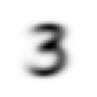

In [18]:
mean3 = stacked_threes.mean(0)
show_image(mean3)

<Axes: >

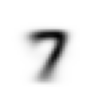

In [19]:
mean7 = stacked_sevens.mean(0)
show_image(mean7)

In [20]:
mean7.shape

torch.Size([28, 28])

In [21]:
a3 = stacked_threes[1]
mad_a3 = (a3 - mean3).abs().mean()
rmse_a3 = (a3 - mean3).pow(2).mean().sqrt()

mad_a3, rmse_a3

(tensor(0.1114), tensor(0.2021))

In [22]:
mad_a7 = (a3 - mean7).abs().mean()
rmse_a7 = (a3 - mean7).pow(2).mean().sqrt()

mad_a7, rmse_a7

(tensor(0.1586), tensor(0.3021))

In [23]:
F.l1_loss(a3.float(), mean3), F.mse_loss(a3.float(), mean3).sqrt()

(tensor(0.1114), tensor(0.2021))

In [24]:
F.l1_loss(a3.float(), mean7), F.mse_loss(a3.float(), mean7).sqrt()

(tensor(0.1586), tensor(0.3021))

In [25]:
(path/'valid').ls()

[Path('valid/7'), Path('valid/3')]

In [26]:
valid_3_tens = torch.stack([tensor(Image.open(p)) for p in (path/'valid/3').ls().sorted()])
valid_3_tens

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

<Axes: >

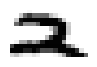

In [27]:
show_image(valid_3_tens[1][4:15, 4:22])

In [28]:
valid_7_tens = torch.stack([tensor(Image.open(p)) for p in (path/'valid/7').ls().sorted()])
valid_7_tens

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

<Axes: >

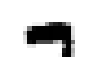

In [29]:
show_image(valid_7_tens[1][4:15, 4:22])

In [30]:
valid_3_tens = valid_3_tens.float()/255
valid_7_tens = valid_7_tens.float()/255
valid_3_tens, valid_7_tens

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         ...,
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 

In [31]:
valid_3_tens.shape, valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

In [32]:
def mnist_dist(img: tensor, target: tensor) -> float:
    return (img - target).abs().mean((-1, -2))

In [33]:
mnist_dist(a3, mean3), mnist_dist(a3, mean7)

(tensor(0.1114), tensor(0.1586))

In [34]:
valid_3_dist = mnist_dist(valid_3_tens, mean3)
valid_3_dist, valid_3_dist.shape

(tensor([0.1280, 0.1623, 0.1242,  ..., 0.1508, 0.1263, 0.1260]),
 torch.Size([1010]))

In [35]:
def is_3(img: tensor):
    return mnist_dist(img, mean3) < mnist_dist(img, mean7)

In [36]:
is_3(a3)

tensor(True)

In [37]:
is_3(valid_3_tens)

tensor([ True,  True,  True,  ..., False,  True,  True])

In [38]:
is_3(valid_7_tens)

tensor([False, False, False,  ..., False, False, False])

In [39]:
accuracy_3 = is_3(valid_3_tens).float().mean()
accuracy_7 = (1 - is_3(valid_7_tens).float()).mean()

accuracy_3, accuracy_7, (accuracy_3 + accuracy_7) / 2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

### Stochastic Gradient Descent (SGD)

We need a process that causes our model to get progressively better at predicting the outputs from the real inputs.

Our mental model is a process that will assign weights to each pixel in the image, and those weights represent the importance of the pixel in contributing to the image we're trying to recognize. The higher the weight, the more important the pixel.

Therefore, we need a function that will progressively get better at determining what those weights should be in order to properly identify the number we're trying to classify.

#### The learning process
1. Initialize the weights.
2. For each image, use these weights to predict whether it appears to be a 3 or a 7.
3. Based on these predictions, calculate how good the model is (its loss).
4. Calculate the gradient, which measures for each weight, how changing that weight would change the loss
5. Step (that is, change) all the weights based on that calculation.
6. Go back to the step 2, and repeat the process.
7. Iterate until you decide to stop the training process (for instance, because the model is good enough or you don't want to wait any longer).

In [40]:
def loss_fn(wt: tensor):
    """Accepts weight and calculates loss using real x and y pairs. Simplified to assume loss is modeled by x**2"""
    return wt**2

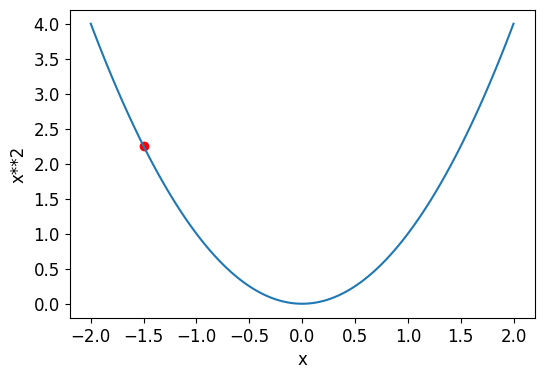

In [41]:
plot_function(loss_fn, 'x', 'x**2')
plt.scatter(-1.5, loss_fn(-1.5), color='red')

In [42]:
# generate a tensor representing a weight value
# use requires_grad_ to prepare pytorch to calculate the gradient for operations involving this tensor
xt = tensor(3.).requires_grad_()
xt

tensor(3., requires_grad=True)

In [43]:
# use the tensor in a function
yt = loss_fn(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

In [44]:
# now calculate the gradient for that coordinate in the curve of the function
# i.e. the gradient where the input (independent variable) is the tensor
# i.e. the value of the derivative where the value of the dependent variable is the tensor
yt.backward() # notice that we're calculating this from the output of the function's invocation, which is where pytorch can track which derivative to apply
xt.grad # the gradient is stored on the tensor, not sure why

tensor(6.)

In [45]:
# illustrate the same process using a vector (rank-1 tensor)
xt = tensor([3., 4., 10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

In [46]:
# modify the loss function to work return a scalar from the vector
def loss_fn(wt):
    return wt.pow(2).sum()

In [47]:
yt = loss_fn(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [48]:
yt.backward()
xt.grad

tensor([ 6.,  8., 20.])

#### A more practical example
We want to determine the speed of a roller coaster at any point in time as it approaches the peak or just after it passes that peak. As it approaches, its speed is reducing, and will be lowest right at the peak. After leaving the peak, the speed begins to increase again as the coaster accelerates downward.

We are collecting the data points manually, so we will have a distribution of points that capture the change in speed. To mimic this, we plot a chart of randomly generated numbers that will look roughly similar to what we expect i.e. speed reducing over time up until a point, then increasing again.

In [52]:
time = torch.arange(0, 20).float()
time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.])

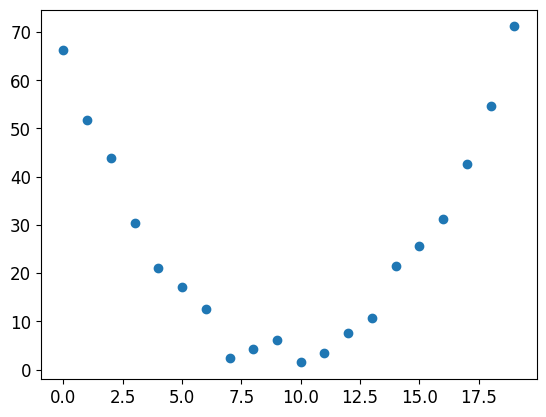

In [71]:
# model speed with some randomness
speed = torch.randn(20) * 3 + 0.75 * (time - 9.5).pow(2) + 1
plt.scatter(time, speed)

By just thinking about what's happening and looking at this shape, we can start by expecting a quadratic function to model this behavior.

In [72]:
def f(t, params):
    a, b, c = params
    return a*(t**2) + b*t + c

The above formulation is really important because it separates the params to be optimized (the values that determine the shape of the quadratic) from the inputs into the quadratic function (the values of `t`). By doing this, we can focus on optimizing only the params until we're satisfied that the quadratic closely fits the data points (speed & time) well.

To reach a level of satisfaction, we must define what we're looking for. In this case, we choose to use a loss function that captures how closely the quadratic function for a given set of params predicts the actual data points. This choice is convenient for 2 reasons:
- it allows us to focus on _minimizing_ the loss because lower loss means better predictions
- minimizing values to find the lowest point on a curve is what the SGD technique does well

In [73]:
def mse(preds: tensor, target: tensor):
    """We use MSE because it's fairly common with continuous data of this sort."""
    return (preds - target).pow(2).mean()

Now we revisit the steps of SGD.

#### Step 1: Initialize the weights

We use random numbers. The SGD process will progressively get better so it's okay to just start with random numbers.

In [75]:
# we use requires_grad_ to make sure derivatives are tracked
# so we can determine the gradient when we need it
params = torch.randn(3).requires_grad_()
params

tensor([-0.3795,  1.5015,  0.1274], requires_grad=True)

#### Step 2: make predictions using the weights